# Food Price Prediction Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Read the Excel file
file = r"C:\Users\Daye Erekosima\Downloads\Untitled spreadsheet.xlsx"
df = pd.read_excel(file)
df.head()

,ItemLabels,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,2017-09-01 00:00:00,...,2024-01-01 00:00:00,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-30 00:00:00,2024-10-01 00:00:00
0,Agric eggs medium size,512.988359,520.157133,507.694497,518.657891,522.713125,514.655959,498.495354,485.187183,487.509186,...,1309.75,1486.69,1621.10,1680.51,1786.66,1935.69,2170.17,2289.19,2487.04,2671.60
1,Agric eggs(medium size price of one),47.418103,42.903737,43.927523,46.218021,45.734869,45.277478,44.317876,42.917186,45.716163,...,116.41,139.28,147.92,150.85,160.31,168.51,185.10,198.63,219.64,235.67
2,"Beans brown,sold loose",353.604172,337.110852,353.277237,357.192036,365.856927,374.255115,382.345275,370.252746,404.837456,...,976.58,1177.93,1234.40,1387.90,2009.23,2292.76,2444.81,2574.63,2738.59,2798.50
3,Beans:white black eye. sold loose,305.530515,309.851381,318.453954,324.038538,332.284612,339.643059,343.963263,335.705296,358.125755,...,921.38,1156.82,1192.22,1313.48,1847.84,2153.87,2309.53,2425.92,2579.02,2603.32
4,Beef Bone in,1001.242821,995.648449,1010.290509,1035.446075,1123.653345,1129.018002,1128.936442,1151.381235,1078.490461,...,2898.12,3115.01,3530.42,3821.74,4145.09,4459.52,4521.29,4660.62,4750.39,4914.62


In [6]:
# Check the data types of the columns
df.dtypes

ItemLabels              object
2017-01-01 00:00:00    float64
2017-02-01 00:00:00    float64
2017-03-01 00:00:00    float64
2017-04-01 00:00:00    float64
                        ...   
2024-06-01 00:00:00    float64
2024-07-01 00:00:00    float64
2024-08-01 00:00:00    float64
2024-09-30 00:00:00    float64
2024-10-01 00:00:00    float64
Length: 95, dtype: object

In [7]:
# Step 1: Melt
df_melted = df.melt(id_vars=["ItemLabels"], var_name="Date", value_name="Price")

# Step 2: Make sure Date is datetime value
df_melted['Date'] = pd.to_datetime(df_melted['Date'])
# Step 3: Split into Month and Year

df_melted['Month'] = df_melted['Date'].dt.month
df_melted['Year'] = df_melted['Date'].dt.year
#df_melted['Quarter'] = df_melted['Date'].dt.quarter


In [8]:
df_melted.head()

,ItemLabels,Date,Price,Month,Year
0,Agric eggs medium size,2017-01-01,512.988359,1,2017
1,Agric eggs(medium size price of one),2017-01-01,47.418103,1,2017
2,"Beans brown,sold loose",2017-01-01,353.604172,1,2017
3,Beans:white black eye. sold loose,2017-01-01,305.530515,1,2017
4,Beef Bone in,2017-01-01,1001.242821,1,2017


In [9]:
# Convert the 'Date' column to string format
df_melted['Date'] = df_melted['Date'].astype('str')

In [10]:
# Create a mapping of dates to population values
population_map = {
    '2017-01-01': 197378751,
    '2017-02-01': 197897826,
    '2017-03-01': 198417992,
    '2017-04-01': 198939251,
    '2017-05-01': 199460605,
    '2017-06-01': 199983056,
    '2017-07-01': 200506605,
    '2017-08-01': 201031254,
    '2017-09-01': 201557004,
    '2017-10-01': 202083858,
    '2017-11-01': 202611819,
    '2017-12-01': 203140889,
    '2018-01-01': 203671070,
    '2018-02-01': 204202364,
    '2018-03-01': 204734774,
    '2018-04-01': 205268303,
    '2018-05-01': 205802954,
    '2018-06-01': 206338730,
    '2018-07-01': 206875633,
    '2018-08-01': 207413667,
    '2018-09-01': 207952834,
    '2018-10-01': 208493138,
    '2018-11-01': 209034583,
    '2018-12-01': 209577171,
    '2019-01-01': 210120908,
    '2019-02-01': 210665801,
    '2019-03-01': 211211855,
    '2019-04-01': 211759076,
    '2019-05-01': 212307468,
    '2019-06-01': 212857035,
    '2019-07-01': 213407783,
    '2019-08-01': 213959718,
    '2019-09-01': 214512846,
    '2019-10-01': 215067170,
    '2019-11-01': 215622696,
    '2019-12-01': 216179427,
    '2020-01-01': 216737370,
    '2020-02-01': 217296528,
    '2020-03-01': 217856906,
    '2020-04-01': 218418506,
    '2020-05-01': 218981330,
    '2020-06-01': 219545384,
    '2020-07-01': 220110668,
    '2020-08-01': 220677185,
    '2020-09-01': 221244938,
    '2020-10-01': 221813931,
    '2020-11-01': 222384168,
    '2020-12-01': 222955654,
    '2021-01-01': 223528394,
    '2021-02-01': 224102391,
    '2021-03-01': 224677647,
    '2021-04-01': 225254164,
    '2021-05-01': 225831946,
    '2021-06-01': 226411002,
    '2021-07-01': 226991334,
    '2021-08-01': 227572947,
    '2021-09-01': 228155844,
    '2021-10-01': 228740030,
    '2021-11-01': 229325507,
    '2021-12-01': 229912283,
    '2022-01-01': 230500361,
    '2022-02-01': 231089742,
    '2022-03-01': 231680429,
    '2022-04-01': 232272423,
    '2022-05-01': 232865726,
    '2022-06-01': 233460339,
    '2022-07-01': 234056265,
    '2022-08-01': 234653507,
    '2022-09-01': 235252066,
    '2022-10-01': 235851946,
    '2022-11-01': 236453150,
    '2022-12-01': 237055682,
    '2023-01-01': 237659545,
    '2023-02-01': 238264743,
    '2023-03-01': 238871282,
    '2023-04-01': 239479167,
    '2023-05-01': 240088403,
    '2023-06-01': 240699002,
    '2023-07-01': 241310969,
    '2023-08-01': 241924311,
    '2023-09-01': 242539038,
    '2023-10-01': 243155159,
    '2023-11-01': 243772681,
    '2023-12-01': 244391613,
    '2024-01-01': 245012965,
    '2024-02-01': 245635745,
    '2024-03-01': 246259960,
    '2024-04-01': 246885621,
    '2024-05-01': 247512734,
    '2024-06-01': 248141307,
    '2024-07-01': 248771347,
    '2024-08-01': 249402860,
    '2024-09-01': 250035853,
    '2024-10-01': 250670335
}



df_melted['Population'] = df_melted['Date'].map(population_map)
df_melted['Date'] = pd.to_datetime(df_melted['Date'])   

In [11]:
# Optional: Rearranging columns nicely
df_final = df_melted[['ItemLabels', 'Month', 'Year', 'Population', 'Price']]

df_final

,ItemLabels,Month,Year,Population,Price
0,Agric eggs medium size,1,2017,197378751.0,512.988359
1,Agric eggs(medium size price of one),1,2017,197378751.0,47.418103
2,"Beans brown,sold loose",1,2017,197378751.0,353.604172
3,Beans:white black eye. sold loose,1,2017,197378751.0,305.530515
4,Beef Bone in,1,2017,197378751.0,1001.242821
...,...,...,...,...,...
4037,"Palm oil: 1 bottle,specify bottle",10,2024,250670335.0,4509.380000
4038,Plantain(ripe),10,2024,250670335.0,1465.990000
4039,Plantain(unripe),10,2024,250670335.0,2719.160000
4040,"Vegetable oil:1 bottle,specify bottle",10,2024,250670335.0,3747.870000


In [13]:
print(df_final['Population'].isna().sum())
df_final['Price'] = round(df_final['Price'], 2)

43


C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_11156\497652653.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Price'] = round(df_final['Price'], 2)


In [14]:
df_final['Population'].fillna(250035853, inplace=True)

C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_11156\1166983316.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['Population'].fillna(250035853, inplace=True)
C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_11156\1166983316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Population'].fillna(250035853, inpla

In [15]:
# Create a mapping dictionary for month numbers to abbreviations
month_map = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar', 
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

# Apply the mapping
df_final['Month'] = df_final['Month'].map(month_map)

C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_11156\4243405116.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Month'] = df_final['Month'].map(month_map)


In [16]:
# I'm doing this to make a copy of the dataset and also to have a better variable name
Saleprice_df = df_final

In [17]:
Saleprice_df.head(50)

,ItemLabels,Month,Year,Population,Price
0,Agric eggs medium size,Jan,2017,197378751.0,512.99
1,Agric eggs(medium size price of one),Jan,2017,197378751.0,47.42
2,"Beans brown,sold loose",Jan,2017,197378751.0,353.60
3,Beans:white black eye. sold loose,Jan,2017,197378751.0,305.53
4,Beef Bone in,Jan,2017,197378751.0,1001.24
5,"Beef,boneless",Jan,2017,197378751.0,1249.48
6,Bread sliced 500g,Jan,2017,197378751.0,302.87
7,Bread unsliced 500g,Jan,2017,197378751.0,270.25
8,Broken Rice (Ofada),Jan,2017,197378751.0,377.41
9,Chicken Feet,Jan,2017,197378751.0,765.28


In [14]:
"""def process_month(df, month_name, year):
    month_df = df[['ITEMS', 'LAGOS']].copy()
    month_df.rename(columns={'ITEMS': 'ItemLabels', 'LAGOS': 'Price'}, inplace=True)
    month_df['Day'] = 1
    month_df['Month'] = month_name
    month_df['Year'] = year
    # Reorder the columns to match the original
    month_df = month_df[['ItemLabels', 'Day', 'Month', 'Year', 'Price']]
    return month_df

# Process each month
feb_processed = process_month(feb_df, 'Feb', 2023)
mar_processed = process_month(march_df, 'Mar', 2023)
apr_processed = process_month(apr_df, 'Apr', 2023)

# Step 4: Combine all datasets
new_data = pd.concat([feb_processed, mar_processed, apr_processed], ignore_index=True)

# Step 5: Append the new data to the original Lagos dataset
Saleprice_df = pd.concat([Saleprice_df, new_data], ignore_index=True)

print("✅ Lagos dataset updated and saved as 'lagos_full_dataset.csv'")
"""

'def process_month(df, month_name, year):\n    month_df = df[[\'ITEMS\', \'LAGOS\']].copy()\n    month_df.rename(columns={\'ITEMS\': \'ItemLabels\', \'LAGOS\': \'Price\'}, inplace=True)\n    month_df[\'Day\'] = 1\n    month_df[\'Month\'] = month_name\n    month_df[\'Year\'] = year\n    # Reorder the columns to match the original\n    month_df = month_df[[\'ItemLabels\', \'Day\', \'Month\', \'Year\', \'Price\']]\n    return month_df\n\n# Process each month\nfeb_processed = process_month(feb_df, \'Feb\', 2023)\nmar_processed = process_month(march_df, \'Mar\', 2023)\napr_processed = process_month(apr_df, \'Apr\', 2023)\n\n# Step 4: Combine all datasets\nnew_data = pd.concat([feb_processed, mar_processed, apr_processed], ignore_index=True)\n\n# Step 5: Append the new data to the original Lagos dataset\nSaleprice_df = pd.concat([Saleprice_df, new_data], ignore_index=True)\n\nprint("✅ Lagos dataset updated and saved as \'lagos_full_dataset.csv\'")\n'

In [18]:
Saleprice_df.shape

(4042, 5)

In [19]:
# Create a mapping of dates to Item categories
items_map = {
    'Agric eggs medium size': 'Perishable',
    'Agric eggs(medium size price of one)': 'Perishable',
    'Beans brown,sold loose': 'Non-Perishable',
    'Beans:white black eye. sold loose': 'Non-Perishable',
    'Beef Bone in': 'Perishable',
    'Beef,boneless': 'Perishable',
    'Bread sliced 500g': 'Perishable',
    'Bread unsliced 500g': 'Perishable',
    'Broken Rice (Ofada)': 'Non-Perishable',
    'Chicken Feet': 'Perishable',
    'Chicken Wings': 'Perishable',
    'Evaporated tinned milk carnation 170g': 'Non-Perishable',
    'Evaporated tinned milk(peak), 170g': 'Non-Perishable',
    'Frozen chicken': 'Perishable',
    'Gari white,sold loose': 'Non-Perishable',
    'Gari yellow,sold loose': 'Non-Perishable',
    'Mudfish (aro) fresh': 'Perishable',
    'Mudfish : dried': 'Non-Perishable',
    'Onion bulb': 'Perishable',
    'Rice agric sold loose': 'Non-Perishable',
    'Rice local sold loose': 'Non-Perishable',
    'Rice Medium Grained': 'Non-Perishable',
    'Rice,imported high quality sold loose': 'Non-Perishable',
    'Tomato': 'Perishable',
    'Yam tuber': 'Perishable',
    'Dried Fish Sardine': 'Non-Perishable',
    'Iced Sardine': 'Perishable',
    'Irish potato': 'Perishable',
    'Sweet potato': 'Perishable',
    'Tilapia fish (epiya) fresh': 'Perishable',
    'Titus:frozen': 'Perishable',
    'Catfish (obokun) fresh': 'Perishable',
    'Catfish :dried': 'Non-Perishable',
    'Catfish Smoked': 'Non-Perishable',
    'Mackerel : frozen': 'Perishable',
    'Groundnut oil: 1 bottle, specify bottle': 'Non-Perishable',
    'Maize grain white sold loose': 'Non-Perishable',
    'Maize grain yellow sold loose': 'Non-Perishable',
    'Palm oil: 1 bottle,specify bottle': 'Non-Perishable',
    'Plantain(ripe)': 'Perishable',
    'Plantain(unripe)': 'Perishable',
    'Vegetable oil:1 bottle,specify bottle': 'Non-Perishable',
    'Wheat flour: prepacked (golden penny 2kg)': 'Non-Perishable'
}

Saleprice_df['Product Category'] = Saleprice_df['ItemLabels'].map(items_map)
Saleprice_df['Product Category'].isna().sum()

0

In [20]:
# Create a map for storage costs
storage_cost_map = {
    'Agric eggs medium size': 'High',
    'Agric eggs(medium size price of one)': 'High',
    'Beans brown,sold loose': 'Low',
    'Beans:white black eye. sold loose': 'Low',
    'Beef Bone in': 'High',
    'Beef,boneless': 'High',
    'Bread sliced 500g': 'Medium',
    'Bread unsliced 500g': 'Medium',
    'Broken Rice (Ofada)': 'Low',
    'Chicken Feet': 'High',
    'Chicken Wings': 'High',
    'Evaporated tinned milk carnation 170g': 'Low',
    'Evaporated tinned milk(peak), 170g': 'Low',
    'Frozen chicken': 'High',
    'Gari white,sold loose': 'Low',
    'Gari yellow,sold loose': 'Low',
    'Mudfish (aro) fresh': 'High',
    'Mudfish : dried': 'Low',
    'Onion bulb': 'Low',
    'Rice agric sold loose': 'Low',
    'Rice local sold loose': 'Low',
    'Rice Medium Grained': 'Low',
    'Rice,imported high quality sold loose': 'Low',
    'Tomato': 'High',
    'Yam tuber': 'Medium',
    'Dried Fish Sardine': 'Low',
    'Iced Sardine': 'High',
    'Irish potato': 'Medium',
    'Sweet potato': 'Medium',
    'Tilapia fish (epiya) fresh': 'High',
    'Titus:frozen': 'High',
    'Catfish (obokun) fresh': 'High',
    'Catfish :dried': 'Low',
    'Catfish Smoked': 'Low',
    'Mackerel : frozen': 'High',
    'Groundnut oil: 1 bottle, specify bottle': 'Low',
    'Maize grain white sold loose': 'Low',
    'Maize grain yellow sold loose': 'Low',
    'Palm oil: 1 bottle,specify bottle': 'Low',
    'Plantain(ripe)': 'Medium',
    'Plantain(unripe)': 'Medium',
    'Vegetable oil:1 bottle,specify bottle': 'Low',
    'Wheat flour: prepacked (golden penny 2kg)': 'Low'
}

Saleprice_df['Storage Cost'] = Saleprice_df['ItemLabels'].map(storage_cost_map)
Saleprice_df['Storage Cost'].isna().sum()

0

In [21]:
# Create a map for geopolitical zones
geopolitical_zone_map = {
    'Agric eggs medium size': 'South West',
    'Agric eggs(medium size price of one)': 'South West',
    'Beans brown,sold loose': 'North Central',
    'Beans:white black eye. sold loose': 'North East',
    'Beef Bone in': 'North West',
    'Beef,boneless': 'North West',
    'Bread sliced 500g': 'South West',
    'Bread unsliced 500g': 'South West',
    'Broken Rice (Ofada)': 'South West',
    'Chicken Feet': 'South East',
    'Chicken Wings': 'South East',
    'Evaporated tinned milk carnation 170g': 'Imported',
    'Evaporated tinned milk(peak), 170g': 'Imported',
    'Frozen chicken': 'South East',
    'Gari white,sold loose': 'South West',
    'Gari yellow,sold loose': 'South West',
    'Mudfish (aro) fresh': 'South South',
    'Mudfish : dried': 'South South',
    'Onion bulb': 'North East',
    'Rice agric sold loose': 'North Central',
    'Rice local sold loose': 'North Central',
    'Rice Medium Grained': 'North Central',
    'Rice,imported high quality sold loose': 'Imported',
    'Tomato': 'North Central',
    'Yam tuber': 'South East',
    'Dried Fish Sardine': 'South South',
    'Iced Sardine': 'Imported',
    'Irish potato': 'North East',
    'Sweet potato': 'South East',
    'Tilapia fish (epiya) fresh': 'South South',
    'Titus:frozen': 'Imported',
    'Catfish (obokun) fresh': 'South West',
    'Catfish :dried': 'South West',
    'Catfish Smoked': 'South West',
    'Mackerel : frozen': 'Imported',
    'Groundnut oil: 1 bottle, specify bottle': 'North East',
    'Maize grain white sold loose': 'North Central',
    'Maize grain yellow sold loose': 'North Central',
    'Palm oil: 1 bottle,specify bottle': 'South South',
    'Plantain(ripe)': 'South East',
    'Plantain(unripe)': 'South East',
    'Vegetable oil:1 bottle,specify bottle': 'Imported',
    'Wheat flour: prepacked (golden penny 2kg)': 'Imported'
}

Saleprice_df['Primary production Zone'] = Saleprice_df['ItemLabels'].map(geopolitical_zone_map)
Saleprice_df['Primary production Zone'].isna().sum()

0

In [22]:
# Reorganize the columns to have a better view
Saleprice_df = Saleprice_df[['ItemLabels', 'Month', 'Year', 'Population', 'Primary production Zone', 'Product Category', 'Storage Cost', 'Price']]

In [23]:
Saleprice_df.sample(20)

,ItemLabels,Month,Year,Population,Primary production Zone,Product Category,Storage Cost,Price
848,Catfish (obokun) fresh,Aug,2018,207413667.0,South West,Perishable,High,1088.95
3218,Maize grain white sold loose,Mar,2023,238871282.0,North Central,Non-Perishable,Low,278.36
2042,Rice Medium Grained,Dec,2020,222955654.0,North Central,Non-Perishable,Low,443.03
567,Broken Rice (Ofada),Feb,2018,204202364.0,South West,Non-Perishable,Low,405.69
1253,Bread sliced 500g,Jun,2019,212857035.0,South West,Perishable,Medium,292.73
3889,Rice agric sold loose,Jul,2024,248771347.0,North Central,Non-Perishable,Low,1218.68
3405,Broken Rice (Ofada),Aug,2023,241924311.0,South West,Non-Perishable,Low,719.77
1369,Maize grain white sold loose,Aug,2019,213959718.0,North Central,Non-Perishable,Low,138.26
3692,Maize grain yellow sold loose,Feb,2024,245635745.0,North Central,Non-Perishable,Low,2445.26
184,"Evaporated tinned milk(peak), 170g",May,2017,199460605.0,Imported,Non-Perishable,Low,198.42


In [24]:
# Create a map for the month names to quarters
quarter_map = {
    'Jan': 'Q1',
    'Feb': 'Q1',
    'Mar': 'Q1',
    'Apr': 'Q2',
    'May': 'Q2',
    'Jun': 'Q2',
    'Jul' : 'Q3',
    'Aug': 'Q3',
    'Sep': 'Q3',
    'Oct': 'Q4',
    'Nov': 'Q4',
    'Dec': 'Q4'
}

Saleprice_df['Quarter'] = Saleprice_df['Month'].map(quarter_map)    


C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_11156\1503043599.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Saleprice_df['Quarter'] = Saleprice_df['Month'].map(quarter_map)


In [25]:
# Create a map for the item categories
item_category_map = {
    'Agric eggs medium size': 'Livestock',
    'Agric eggs(medium size price of one)': 'Livestock',
    'Beans brown,sold loose': 'Crops',
    'Beans:white black eye. sold loose': 'Crops',
    'Beef Bone in': 'Livestock',
    'Beef,boneless': 'Livestock',
    'Bread sliced 500g': 'Crops',  # (as a product of wheat)
    'Bread unsliced 500g': 'Crops',  # (as a product of wheat)
    'Broken Rice (Ofada)': 'Crops',
    'Chicken Feet': 'Livestock',
    'Chicken Wings': 'Livestock',
    'Evaporated tinned milk carnation 170g': 'Imported',
    'Evaporated tinned milk(peak), 170g': 'Imported',
    'Frozen chicken': 'Livestock',
    'Gari white,sold loose': 'Crops',
    'Gari yellow,sold loose': 'Crops',
    'Mudfish (aro) fresh': 'Fishing',
    'Mudfish : dried': 'Fishing',
    'Onion bulb': 'Crops',
    'Rice agric sold loose': 'Crops',
    'Rice local sold loose': 'Crops',
    'Rice Medium Grained': 'Crops',
    'Rice,imported high quality sold loose': 'Imported',
    'Tomato': 'Crops',
    'Yam tuber': 'Crops',
    'Dried Fish Sardine': 'Fishing',
    'Iced Sardine': 'Fishing',
    'Irish potato': 'Crops',
    'Sweet potato': 'Crops',
    'Tilapia fish (epiya) fresh': 'Fishing',
    'Titus:frozen': 'Fishing',
    'Catfish (obokun) fresh': 'Fishing',
    'Catfish :dried': 'Fishing',
    'Catfish Smoked': 'Fishing',
    'Mackerel : frozen': 'Fishing',
    'Groundnut oil: 1 bottle, specify bottle': 'Crops',
    'Maize grain white sold loose': 'Crops',
    'Maize grain yellow sold loose': 'Crops',
    'Palm oil: 1 bottle,specify bottle': 'Crops',
    'Plantain(ripe)': 'Crops',
    'Plantain(unripe)': 'Crops',
    'Vegetable oil:1 bottle,specify bottle': 'Crops',
    'Wheat flour: prepacked (golden penny 2kg)': 'Crops'
}

Saleprice_df['Product'] = Saleprice_df['ItemLabels'].map(item_category_map)
Saleprice_df['Product'].isna().sum()

C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_11156\3115325827.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Saleprice_df['Product'] = Saleprice_df['ItemLabels'].map(item_category_map)


0

In [26]:
Saleprice_df.sample(20)

,ItemLabels,Month,Year,Population,Primary production Zone,Product Category,Storage Cost,Price,Quarter,Product
2577,Plantain(unripe),Dec,2021,229912283.0,South East,Perishable,Medium,261.15,Q4,Crops
3762,Rice Medium Grained,Apr,2024,246885621.0,North Central,Non-Perishable,Low,2912.03,Q2,Crops
2515,Rice Medium Grained,Nov,2021,229325507.0,North Central,Non-Perishable,Low,476.67,Q4,Crops
3443,Beans:white black eye. sold loose,Sep,2023,242539038.0,North East,Non-Perishable,Low,691.46,Q3,Crops
3130,Mackerel : frozen,Jan,2023,237659545.0,Imported,Perishable,High,1602.21,Q1,Fishing
2049,Sweet potato,Dec,2020,222955654.0,South East,Perishable,Medium,154.98,Q4,Crops
2285,Bread sliced 500g,Jun,2021,226411002.0,South West,Perishable,Medium,355.78,Q2,Crops
3189,Bread unsliced 500g,Mar,2023,238871282.0,South West,Perishable,Medium,518.14,Q1,Crops
1044,"Evaporated tinned milk(peak), 170g",Jan,2019,210120908.0,Imported,Non-Perishable,Low,190.68,Q1,Imported
3427,Titus:frozen,Aug,2023,241924311.0,Imported,Perishable,High,593.24,Q3,Fishing


In [55]:
exchange_df = pd.read_csv(r'C:\Users\Daye Erekosima\Projects\Sales price prediction model\Exchange rate.xlsx - Sheet1.csv', parse_dates=['Date'])
exchange_df = exchange_df[exchange_df['Currency'].str.contains('US')]
exchange_df.head()

,Currency,Date,Buying Rate,Central Rate,Selling Rate
10,US DOLLAR,2025-04-23,1601.3043,1601.8043,1602.3043
22,US DOLLAR,2025-04-22,1601.6318,1602.1318,1602.6318
34,US DOLLAR,2025-04-17,1598.9384,1599.4384,1599.9384
46,US DOLLAR,2025-04-16,1598.7991,1599.2991,1599.7991
58,US DOLLAR,2025-04-15,1597.9548,1598.4548,1598.9548


In [56]:
exchange_df = exchange_df[['Currency', 'Date', 'Selling Rate']]


In [57]:
exchange_df['Year'] = exchange_df['Date'].dt.year
exchange_df['Month'] = exchange_df['Date'].dt.month

In [58]:
exchange_df.drop(columns=['Date', 'Currency'], inplace=True)
exchange_df.rename(columns={'Selling Rate': 'Exchange Rate $'}, inplace=True)
exchange_df.head()

,Exchange Rate $,Year,Month
10,1602.3043,2025,4
22,1602.6318,2025,4
34,1599.9384,2025,4
46,1599.7991,2025,4
58,1598.9548,2025,4


In [67]:
month_map = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar', 
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

exchange_df['Month'] = exchange_df['Month'].map(month_map)

In [69]:
food_price_df = Saleprice_df.merge(exchange_df, on=['Year', 'Month'], how='left')
food_price_df['Exchange Rate $'].isna().sum()

0

In [70]:
food_price_df.sample(20)

,ItemLabels,Month,Year,Population,Primary production Zone,Product Category,Storage Cost,Price,Quarter,Product,Exchange Rate $
68483,Mudfish : dried,Jul,2023,241310969.0,South South,Non-Perishable,Low,3098.34,Q3,Fishing,786.030
12593,Bread unsliced 500g,Mar,2018,204734774.0,South West,Perishable,Medium,278.61,Q1,Crops,305.850
59816,"Evaporated tinned milk(peak), 170g",Sep,2022,235252066.0,Imported,Non-Perishable,Low,295.29,Q3,Imported,429.680
20947,Dried Fish Sardine,Dec,2018,209577171.0,South South,Non-Perishable,Low,1342.97,Q4,Fishing,306.950
48485,Yam tuber,Aug,2021,227572947.0,South East,Perishable,Medium,305.48,Q3,Crops,410.110
46860,Titus:frozen,Jun,2021,226411002.0,Imported,Perishable,High,1151.08,Q2,Fishing,410.180
28879,Tilapia fish (epiya) fresh,Sep,2019,214512846.0,South South,Perishable,High,813.43,Q3,Fishing,306.950
14048,"Groundnut oil: 1 bottle, specify bottle",Apr,2018,205268303.0,North East,Non-Perishable,Low,584.47,Q2,Crops,305.600
53297,Plantain(ripe),Jan,2022,230500361.0,South East,Perishable,Medium,288.51,Q1,Crops,414.440
12989,Iced Sardine,Mar,2018,204734774.0,Imported,Perishable,High,899.67,Q1,Fishing,305.800


In [73]:
food_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82388 entries, 0 to 82387
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ItemLabels               82388 non-null  object 
 1   Month                    82388 non-null  object 
 2   Year                     82388 non-null  int32  
 3   Population               82388 non-null  float64
 4   Primary production Zone  82388 non-null  object 
 5   Product Category         82388 non-null  object 
 6   Storage Cost             82388 non-null  object 
 7   Price                    82388 non-null  float64
 8   Quarter                  82388 non-null  object 
 9   Product                  82388 non-null  object 
 10  Exchange Rate $          82388 non-null  float64
dtypes: float64(3), int32(1), object(7)
memory usage: 6.6+ MB


In [74]:
food_price_df['Price'].corr(food_price_df['Exchange Rate $'])

0.5941060212797376

# Visualization


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette('PuRd')

C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_4480\293931345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ItemLabels', y='Price', data=month_data, ax=ax[i], palette='viridis')
C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_4480\293931345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ItemLabels', y='Price', data=month_data, ax=ax[i], palette='viridis')
C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_4480\293931345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ItemLabels', y='Price', data=month_dat

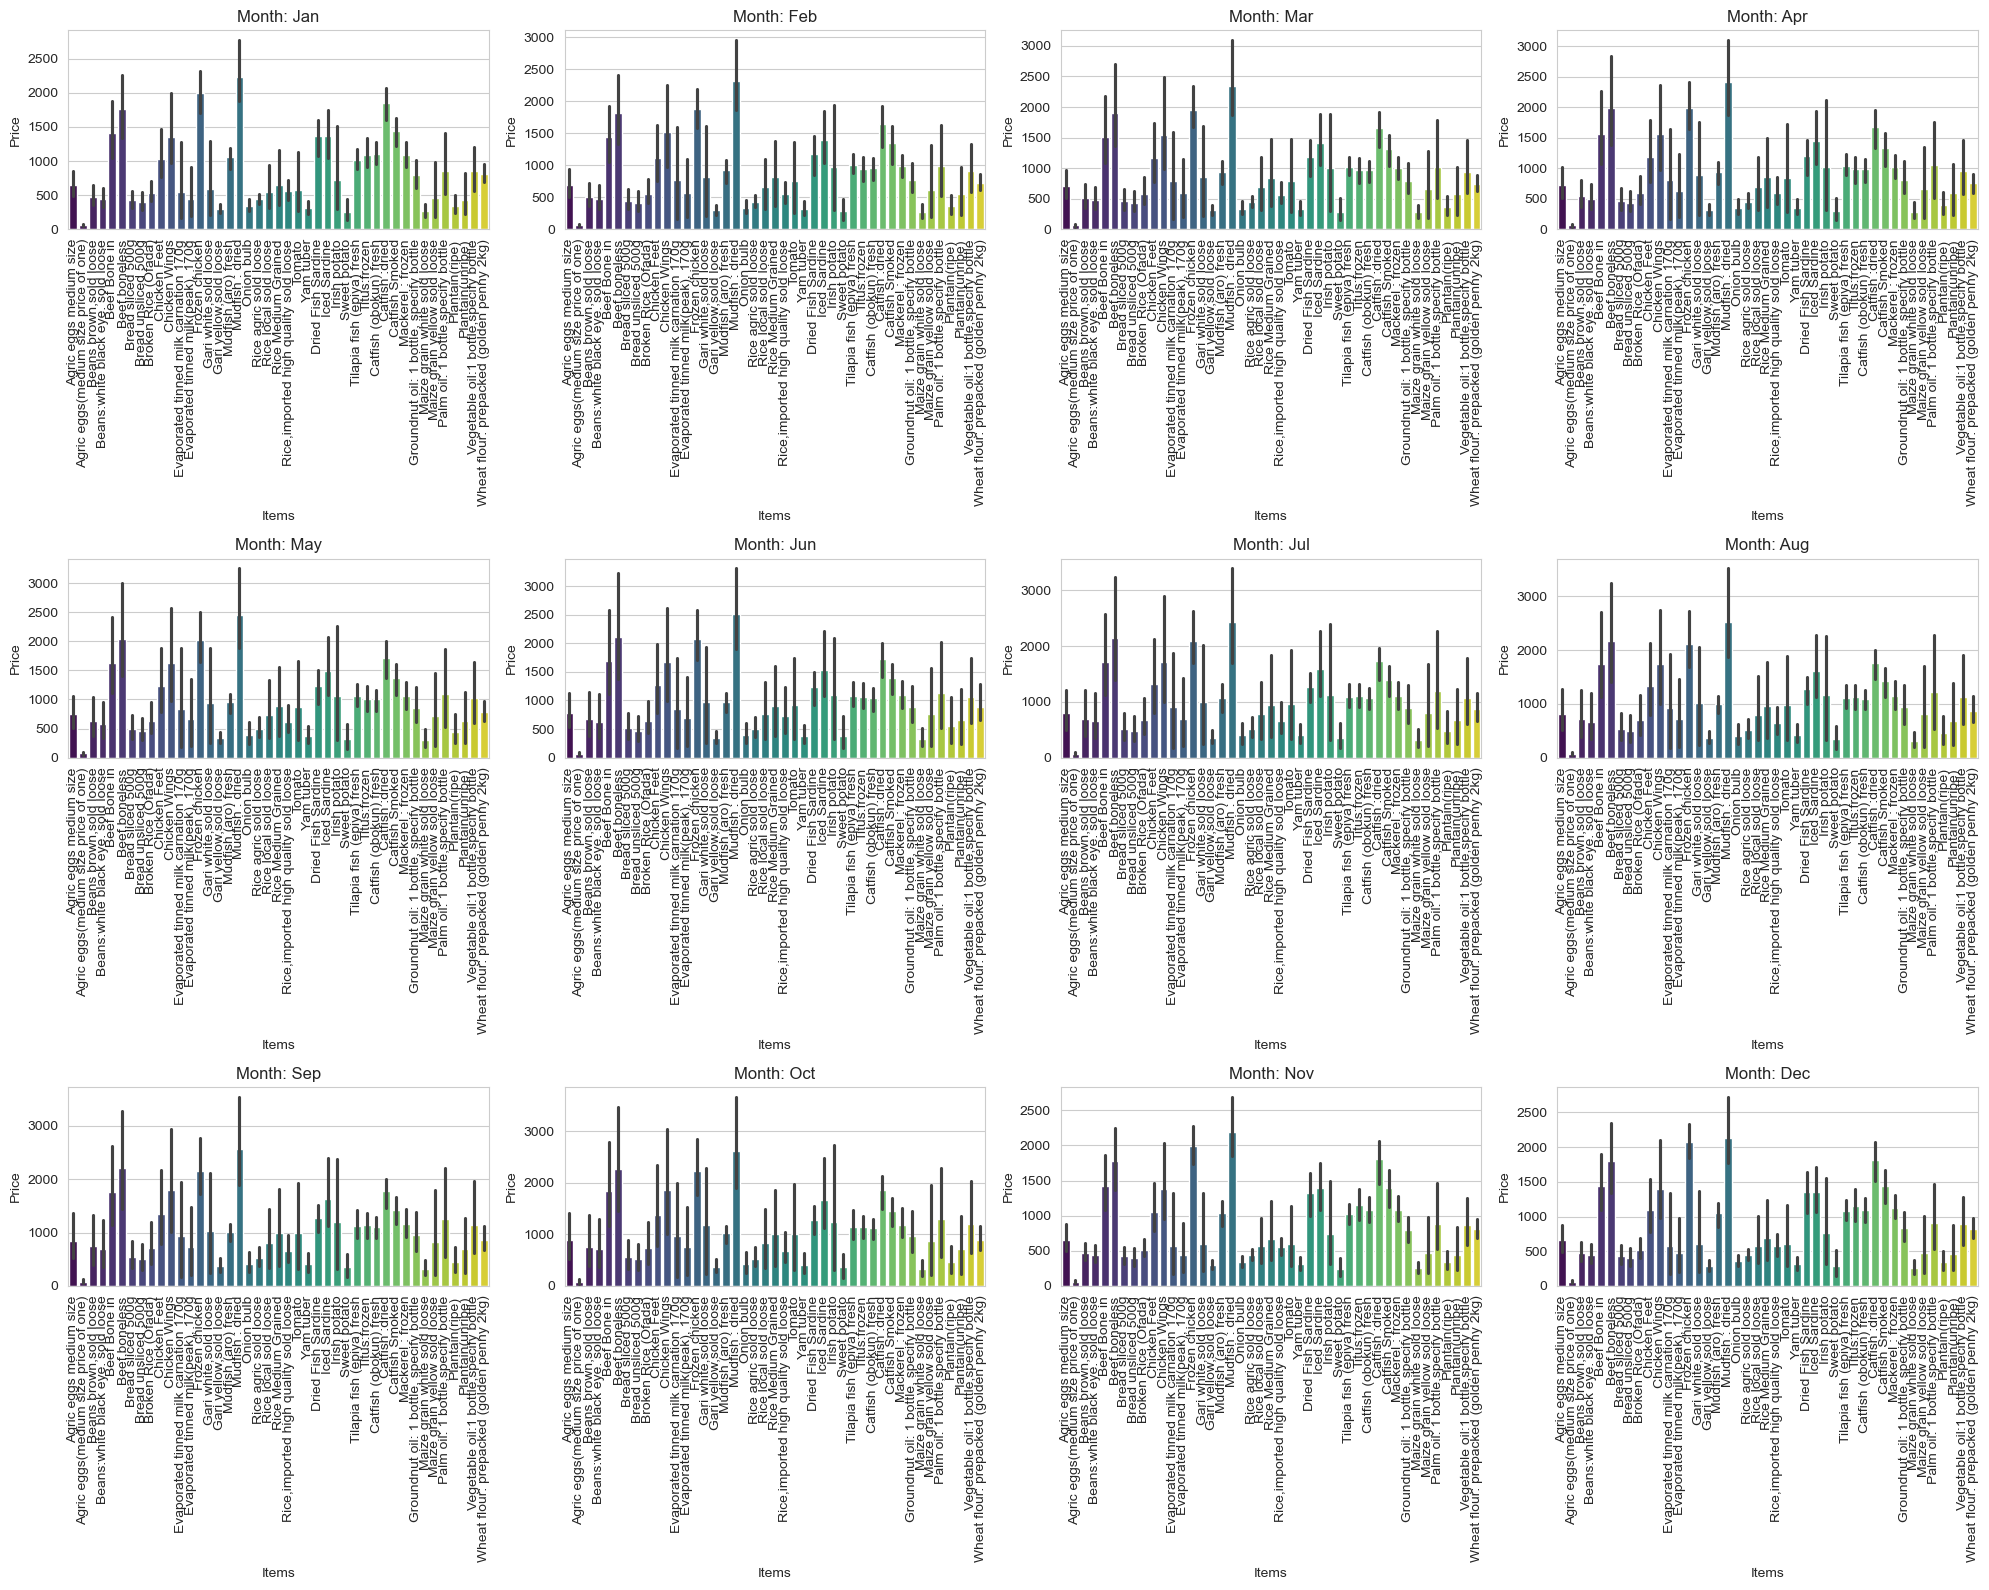

In [25]:
fig, ax = plt.subplots(3,4,figsize=(20,16))
ax = ax.flatten()
# Create a barplot for each month    
months = Saleprice_df['Month'].unique()

for i, month in enumerate(months):
    month_data = Saleprice_df[Saleprice_df['Month'] == month]
    sns.barplot(x='ItemLabels', y='Price', data=month_data, ax=ax[i], palette='viridis')
    ax[i].set_xlabel('Items')
    ax[i].set_title(f'Month: {month}')
    ax[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()     

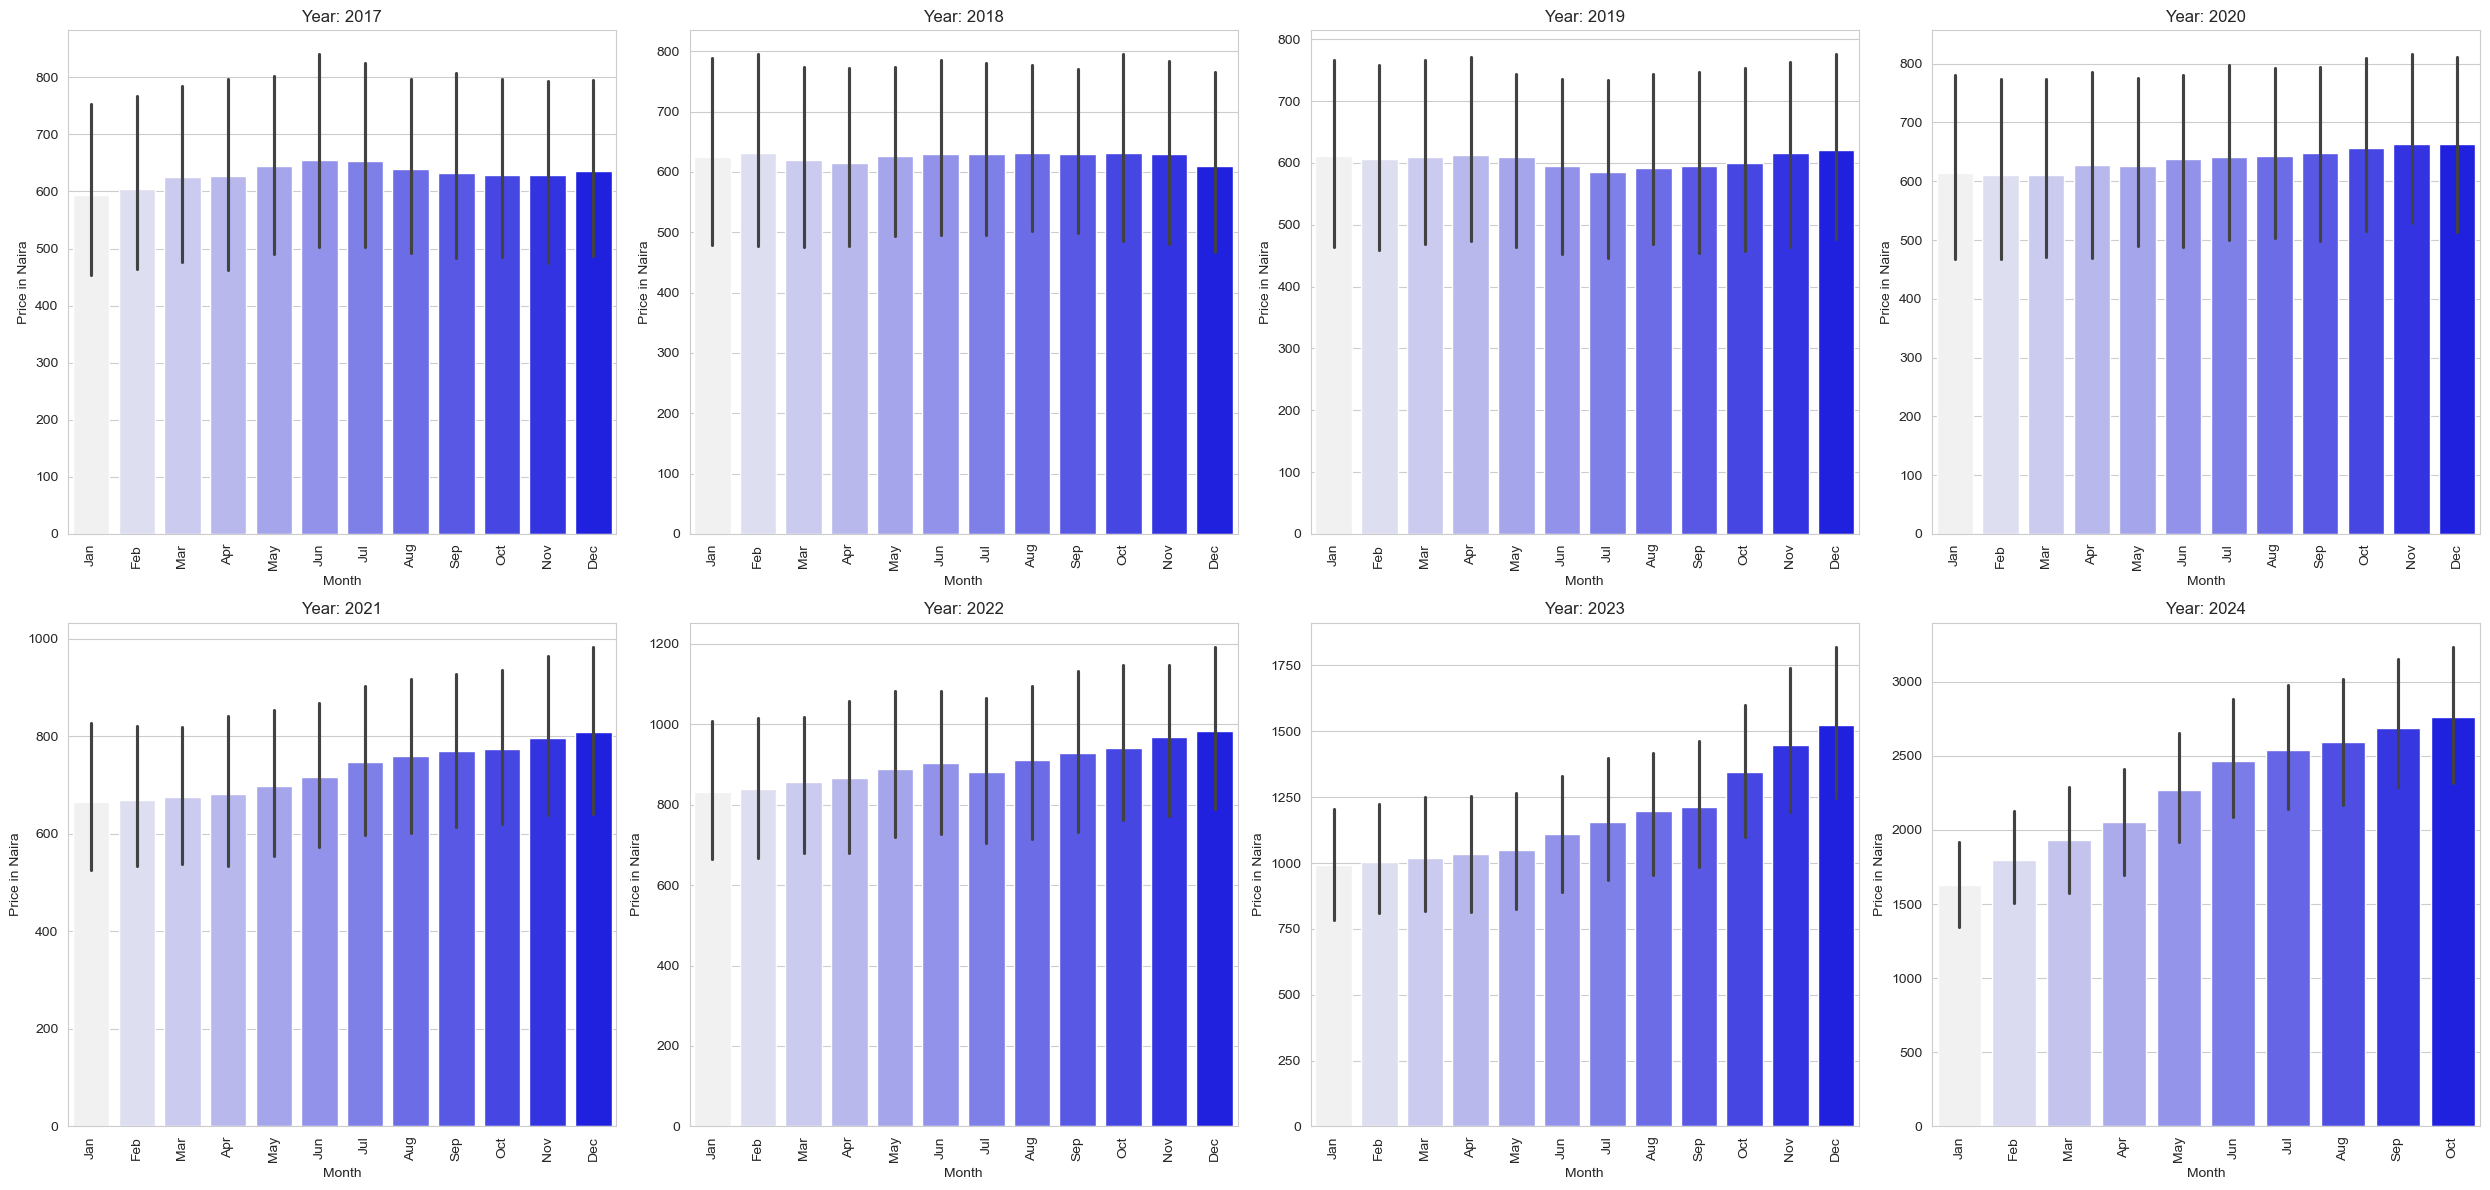

In [26]:
fig, ax = plt.subplots(2, 4, figsize=(25, 12))  # 2 rows x 4 columns = 8 plots (for 8 years)
ax = ax.flatten()

years = sorted(Saleprice_df['Year'].unique())

for i, year in enumerate(years):
    year_data = Saleprice_df[Saleprice_df['Year'] == year]
    sns.barplot(x='Month', y='Price', data=year_data, ax=ax[i], hue='Month', palette='light:blue')
    ax[i].set_title(f'Year: {year}')
    ax[i].set_xlabel('Month')
    ax[i].set_ylabel('Price in Naira')   
    ax[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [27]:
import numpy as np

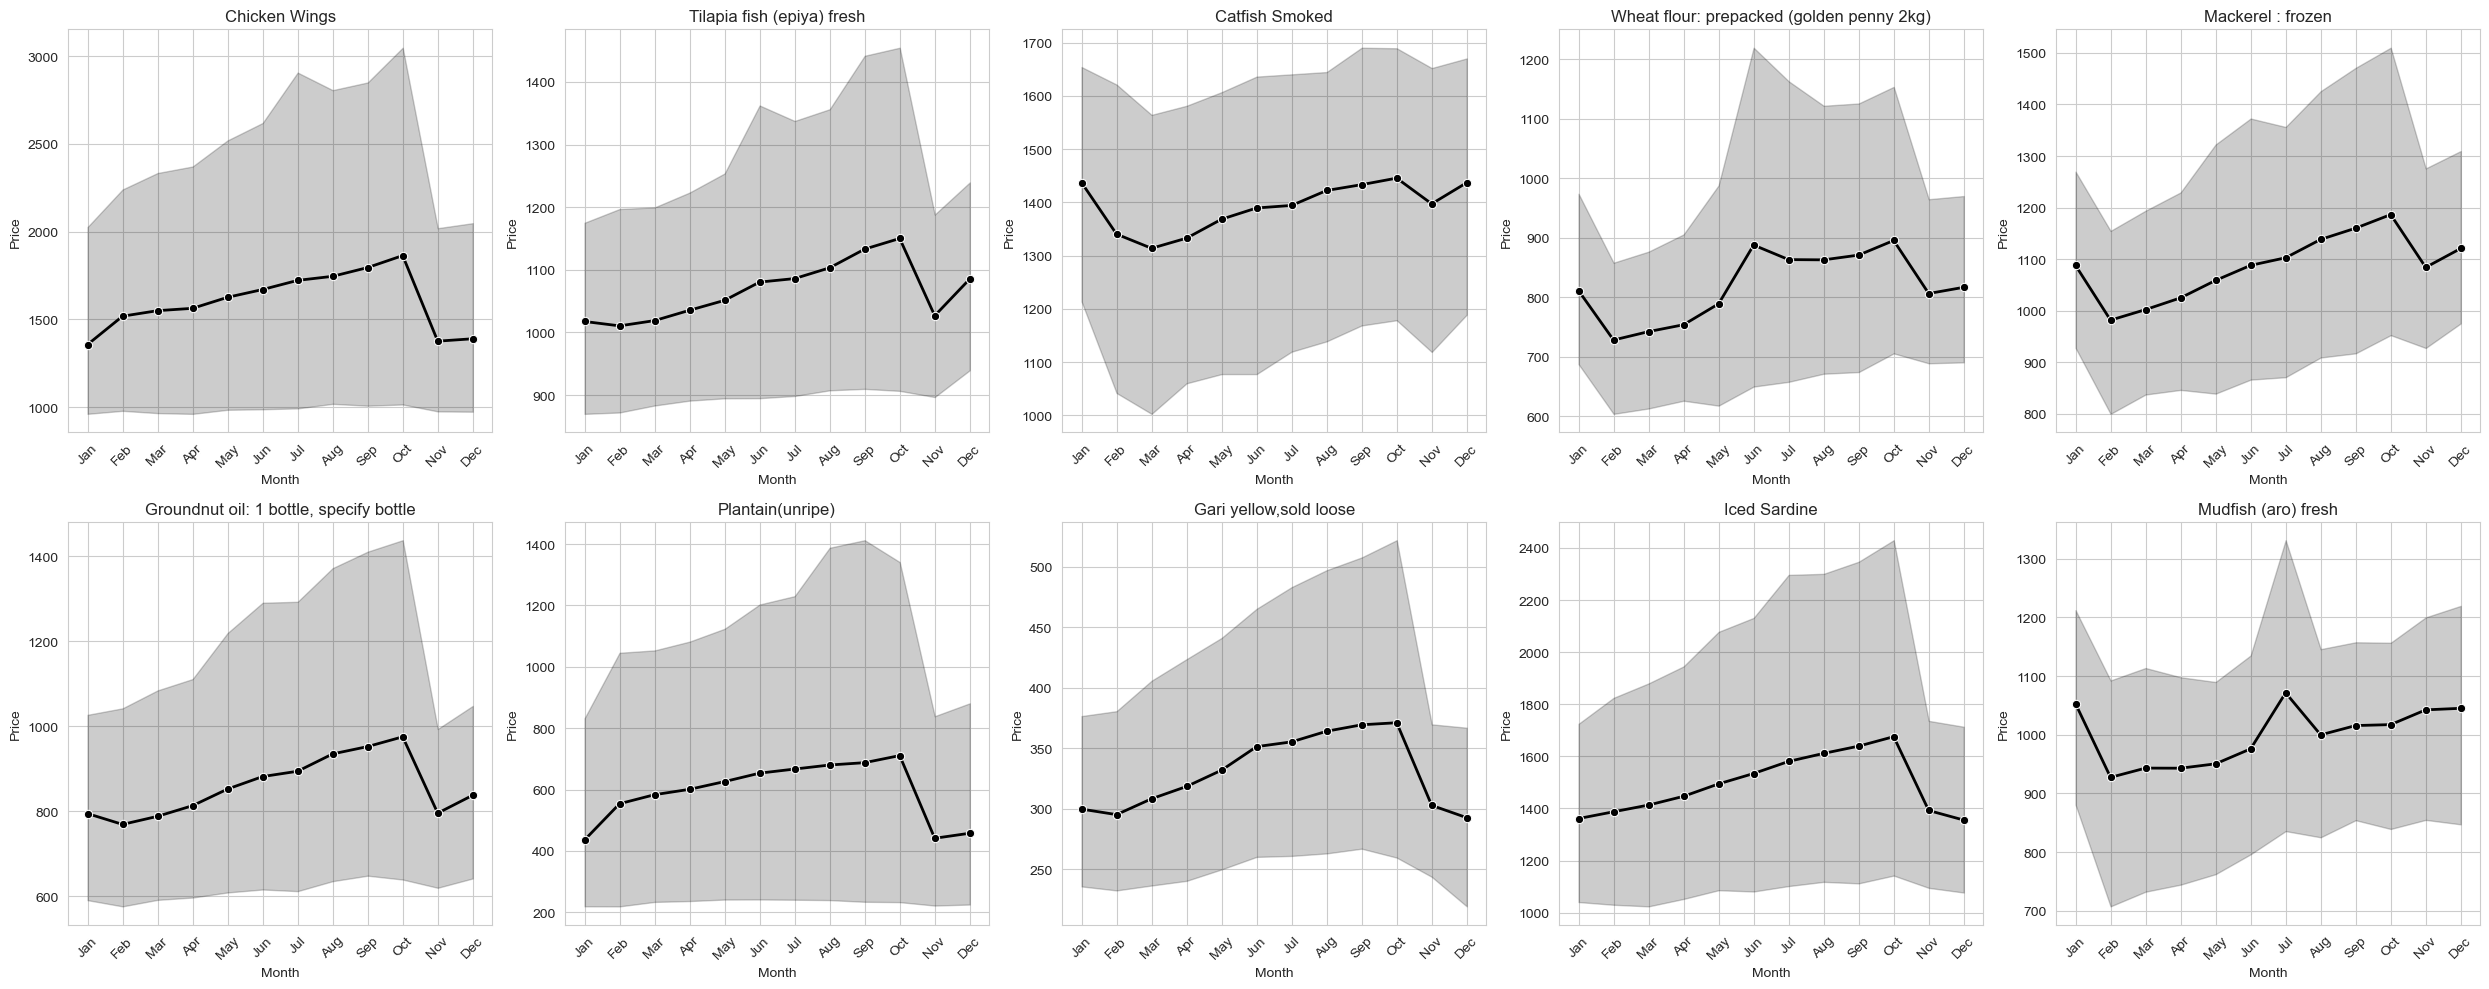

In [28]:
# Pick 10 random unique items
random_items = Saleprice_df['ItemLabels'].unique()
random_items = np.random.choice(random_items, size=10, replace=False)

# Filter the data for these 10 items
filtered_df = Saleprice_df[Saleprice_df['ItemLabels'].isin(random_items)]

# Setup subplots (let’s do 2 rows x 5 columns)
fig, ax = plt.subplots(2, 5, figsize=(25, 10))
ax = ax.flatten()

for i, item in enumerate(random_items):
    item_data = filtered_df[filtered_df['ItemLabels'] == item]
    sns.lineplot(x='Month', y='Price', data=item_data, marker='o', ax=ax[i], color='black', linewidth=2)
    ax[i].set_title(item)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_xlabel('Month')
    ax[i].set_ylabel('Price')

plt.tight_layout()
plt.show()

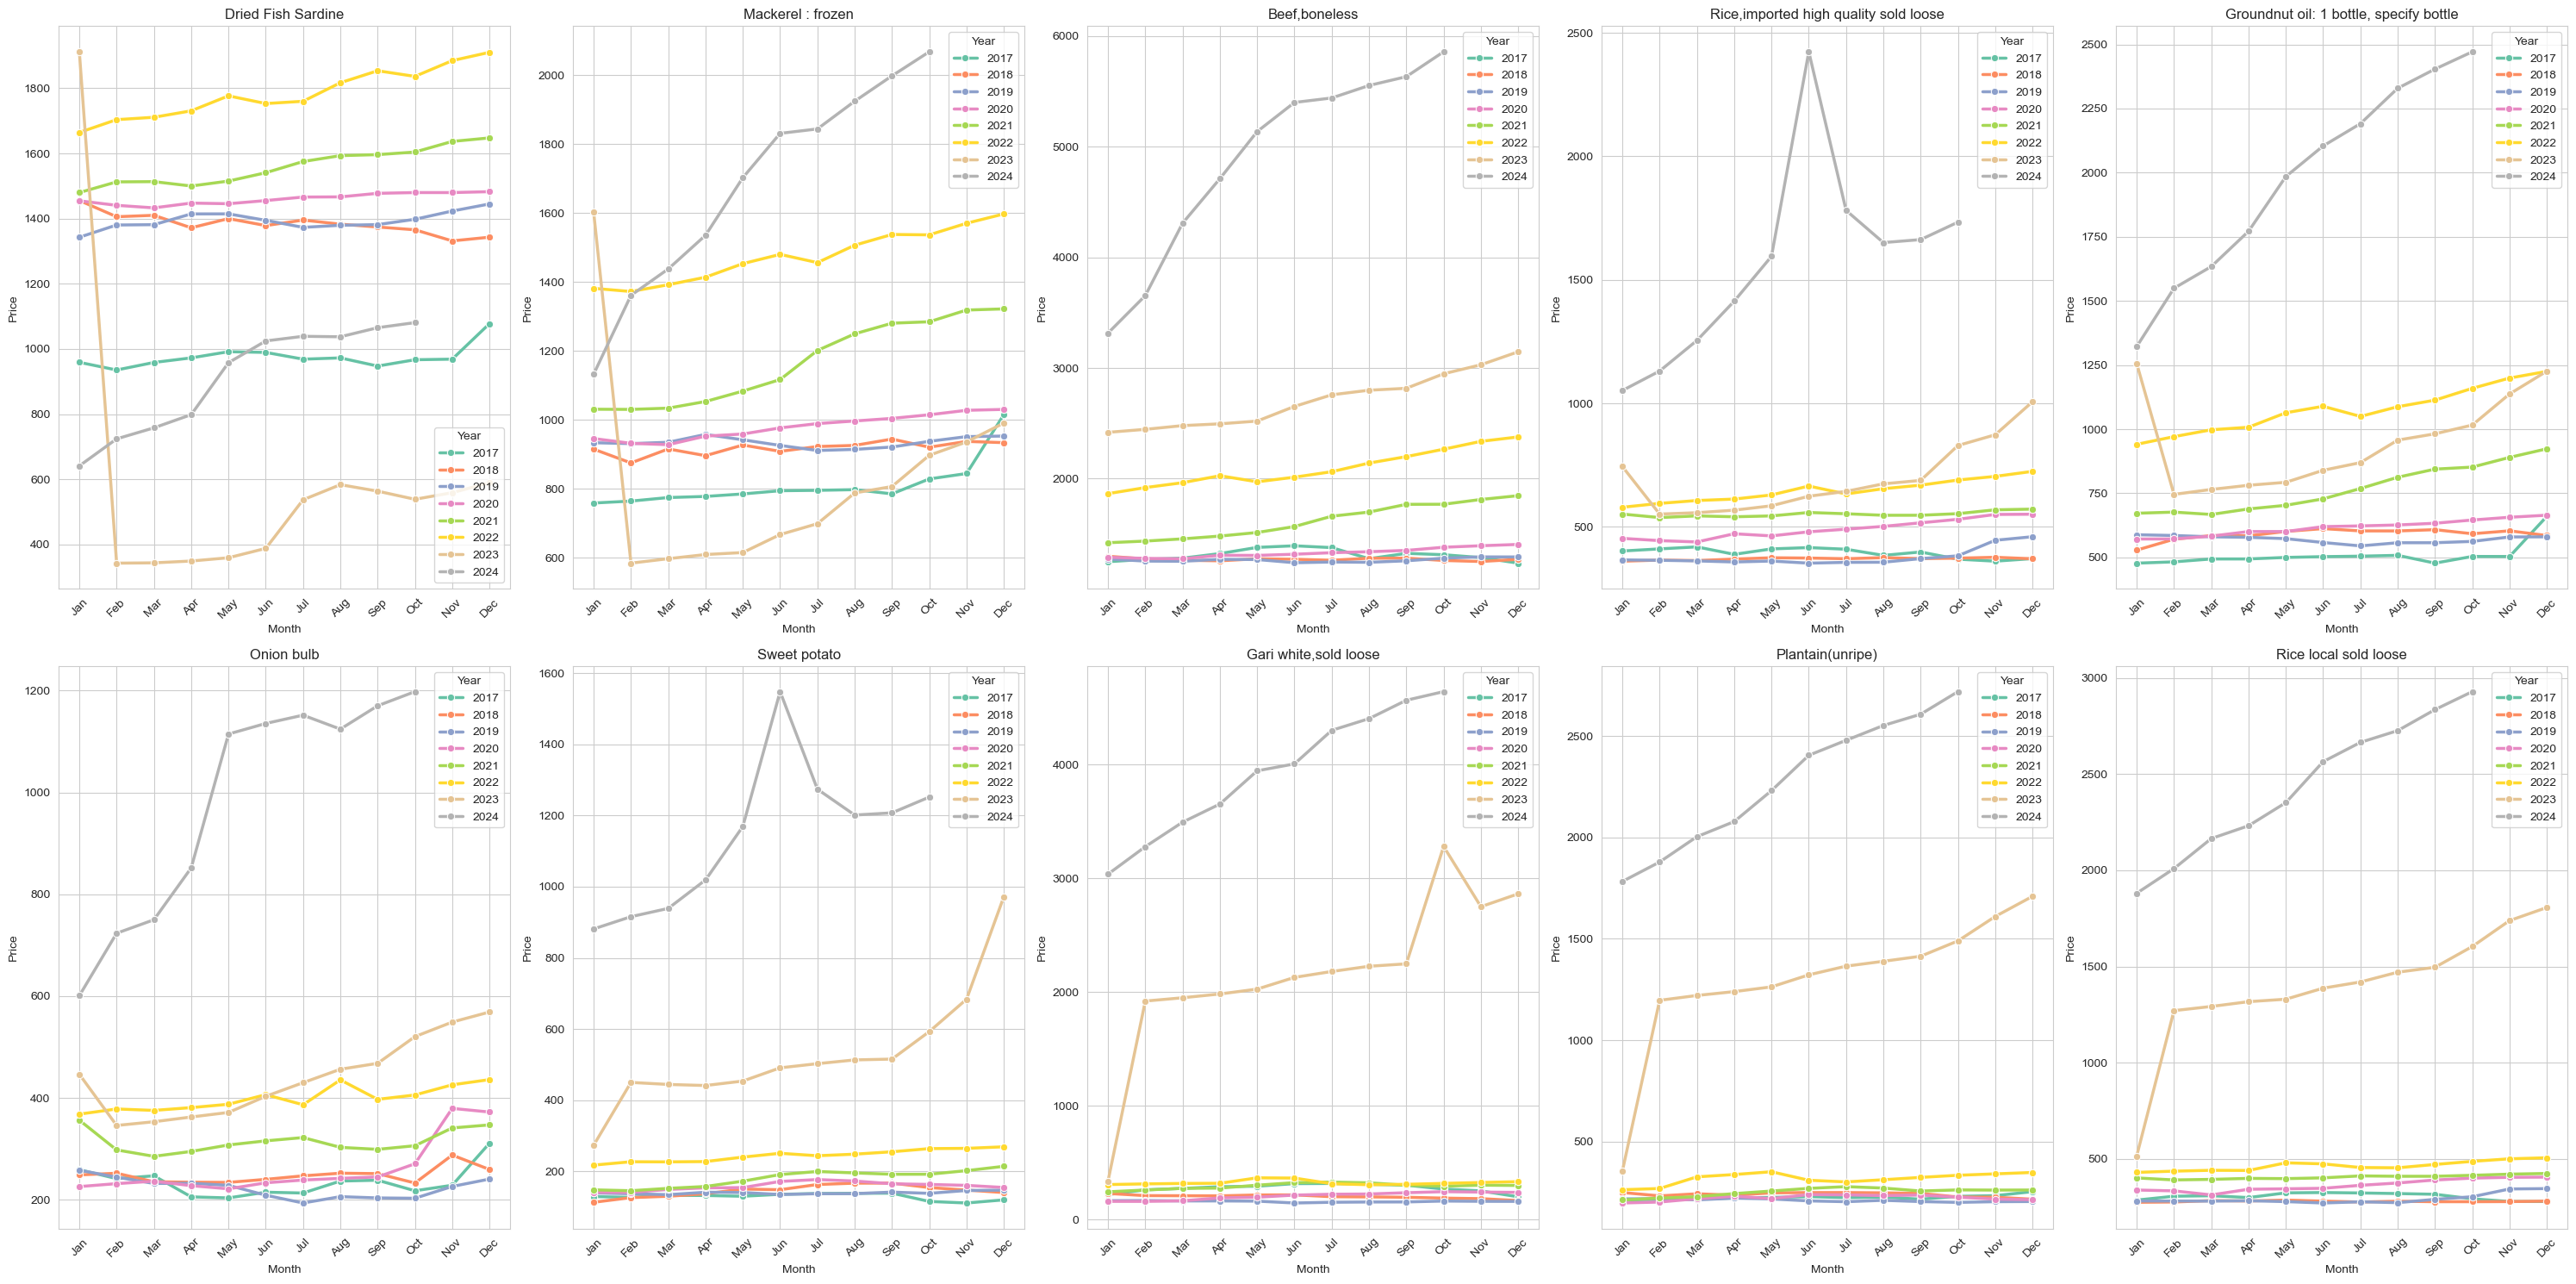

In [29]:
# Pick random 10 items
random_items = Saleprice_df['ItemLabels'].dropna().unique()
random_items = np.random.choice(random_items, size=10, replace=False)

filtered_df = Saleprice_df[Saleprice_df['ItemLabels'].isin(random_items)]

# Define a color palette for each year (assuming there are not too many unique years)
years = filtered_df['Year'].unique()
color_palette = sns.color_palette("Set2", n_colors=len(years))

# Increase the figure size
fig, ax = plt.subplots(2, 5, figsize=(30, 15))  # Large size
ax = ax.flatten()

for i, item in enumerate(random_items):
    item_data = filtered_df[filtered_df['ItemLabels'] == item]
    
    # Plot separately for each year, using the color palette
    for j, year in enumerate(item_data['Year'].unique()):
        year_data = item_data[item_data['Year'] == year]
        sns.lineplot(
            x='Month', y='Price', data=year_data,
            marker='o', color=color_palette[j], linewidth=2.5, 
            errorbar=None, ax=ax[i], label=year
        )
    
    ax[i].set_title(item)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_xlabel('Month')
    ax[i].set_ylabel('Price')
    #ax[i].set_ylim(200, 2800)  # Set the y-axis range from 200 to 2800
    ax[i].legend(title='Year')

plt.tight_layout()
plt.show()


Storage Cost
Low       2068
High      1316
Medium     658
Name: count, dtype: int64


C:\Users\Daye Erekosima\AppData\Local\Temp\ipykernel_4480\1898954128.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Storage Cost', y='Price', data=storage_cost_mean_price, palette='viridis')


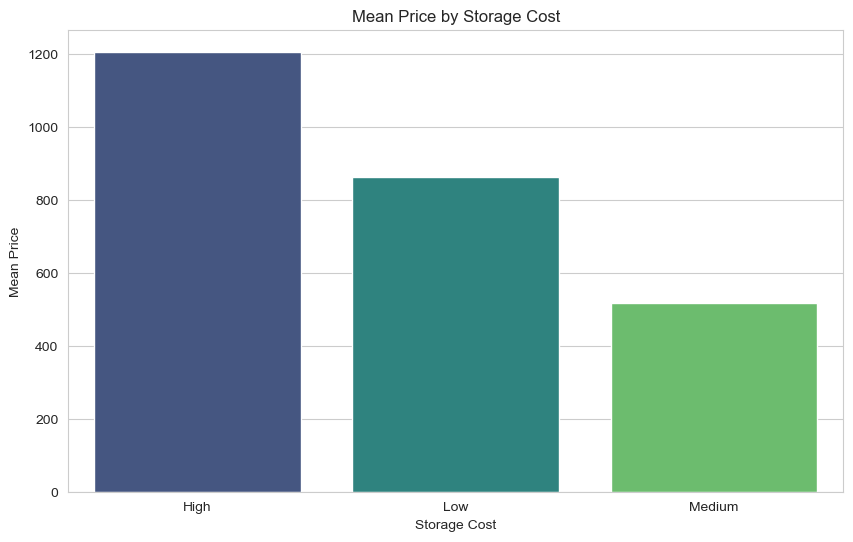

In [30]:
# Group by 'Storage Cost' and calculate the mean price
storage_cost_mean_price = Saleprice_df.groupby('Storage Cost')['Price'].mean().reset_index()

print(Saleprice_df['Storage Cost'].value_counts())

# Plot the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Storage Cost', y='Price', data=storage_cost_mean_price, palette='viridis')
plt.title('Mean Price by Storage Cost')
plt.xlabel('Storage Cost')
plt.ylabel('Mean Price')
plt.show()